# MindReader Clinical Trial Study & Pipeline Comparison Prototype

This notebook demonstrates how MindReader can convert raw clinical trial registry data into structured, normalized, weighted, and explainable study/pipeline comparisons.

The goal is not to build a chatbot yet. The goal is to prove that we can compare clinical studies and pipelines on clinically meaningful dimensions such as efficacy, safety, tolerability, patient convenience, endpoint quality, cost/access, regulatory maturity, and pipeline strength.

This notebook is designed for approval. After approval, the method can be converted into a repeatable product pipeline.


## Why This Matters

Clinical trial records are difficult to compare manually because each study may have different endpoints, populations, phases, sponsors, results availability, safety signals, and design choices.

MindReader’s value is to convert these scattered fields into structured intelligence:
- What looks clinically meaningful?
- What looks safe or risky?
- Which therapy is easier for patients?
- Which pipeline looks more mature?
- Which studies have stronger evidence?
- Where is data missing?


In [3]:
import os
import glob
import json
import math
import urllib.request
import urllib.parse
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, RobustScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')


In [4]:
def find_clinical_trials_csv():
    preferred = 'clinical_trials(1).csv'
    if os.path.exists(preferred):
        return preferred

    candidates = glob.glob('*clinical_trials*.csv')
    if not candidates:
        raise FileNotFoundError('No clinical trial CSV found in current directory.')
    return candidates[0]

csv_path = find_clinical_trials_csv()
df = pd.read_csv(csv_path)

print('Loaded:', csv_path)
print('Shape:', df.shape)
display(df.head())
display(df.isna().sum().sort_values(ascending=False))


Loaded: clinical_trials.csv
Shape: (7000, 12)


,nct_id,brief_title,official_title,category,status,start_date,completion_date,sponsor,study_type,phase,enrollment,conditions
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy,Effect of Treatment of Hyperuricemia on Progression of Diabetic Nephropathy in Patients With Type II Diabetes Mellitus and Stage III Chronic Kidney Disease.,Autoimmune,UNKNOWN,2021-04-15,2022-12-30,Assiut University,OBSERVATIONAL,NaN,200,"Hyperuricemia, Diabetic Nephropathies"
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Children With Diabetes and Celiac Disease.,Studying the Effect of Gluten Free Diet Alone Versus Combination of Gluten Free Diet With Either Carbohydrate Count or Dietary Approach to Reduce Hypertensi...,Autoimmune,UNKNOWN,2021-11-15,2022-11-11,University of Jordan,INTERVENTIONAL,NaN,45,"Diabetes Mellitus, Type 1, Celiac Disease in Children"
2,NCT05945576,IDMet (RaDiCo Cohort) (RaDiCo-IDMet),National Cohort on Imprinting Disorders and Their Metabolic Consequences,Autoimmune,RECRUITING,2017-03-10,2028-03,"Institut National de la Santé Et de la Recherche Médicale, France",OBSERVATIONAL,NaN,2000,"Silver Russell Syndrome, Beckwith-Wiedemann Syndrome, Transient Neonatal Diabetes Mellitus, Angelman Syndrome, Prader-Willi Syndrome, Temple Syndrome, Kagam..."
3,NCT06530940,Diagnostic Interest of the Buccal Schirmer Test in Xerostomia During Sjögren's Syndrome: XERODIAG,Diagnostic Interest of the Buccal Schirmer Test in Xerostomia During Sjögren's Syndrome: XERODIAG,Autoimmune,NOT_YET_RECRUITING,2024-08-19,2024-12-31,University Tunis El Manar,OBSERVATIONAL,NaN,180,"Sjogren's Syndrome, Xerostomia, Diagnosis"
4,NCT03715140,Crucumin Effects on the Immune System in Osteoarthritis Patients,Evaluation of the Crucumin Effects on the Cellular and Humoral Immune Systems in Osteoarthritis Patients; a Randomised Double Blind Placebo Control Clinical...,Autoimmune,UNKNOWN,2019-05-01,2020-12-30,Mashhad University of Medical Sciences,INTERVENTIONAL,PHASE3,30,Osteoarthritis


phase              3623
completion_date     229
official_title       91
start_date           40
nct_id                0
brief_title           0
category              0
status                0
sponsor               0
study_type            0
enrollment            0
conditions            0
dtype: int64

## Dataset Understanding

The broad dataset is useful for pipeline-level analysis. It contains trial identifiers, category, sponsor, phase, status, enrollment, dates, and conditions.

However, broad CSV fields are not enough for deep study comparison. To compare studies properly, we need detailed records from ClinicalTrials.gov API v2 using each NCT ID.

### Key Fields Description:
* `nct_id`: The unique identifier for the clinical trial (e.g. NCT04799925).
* `brief_title`: The short title of the study.
* `official_title`: The detailed official title of the study.
* `category`: The therapeutic area category (e.g. Oncology, Autoimmune).
* `status`: The current status of the trial (e.g. Completed, Recruiting).
* `start_date`: The official start date of the study.
* `completion_date`: The completion date of the study.
* `sponsor`: The lead organization sponsor.
* `study_type`: The nature of the study design (e.g. Interventional, Observational).
* `phase`: The phase of development (e.g. Phase 1, Phase 2, Phase 3, Phase 4).
* `enrollment`: The planned or actual sample size.
* `conditions`: The clinical conditions or diseases studied.


In [5]:
def fetch_in_depth_trial_data(nct_id, timeout=20):
    url = f'https://clinicaltrials.gov/api/v2/studies/{nct_id}'
    req = urllib.request.Request(
        url,
        headers={'User-Agent': 'MindReader-Clinical-Trial-Prototype/1.0'}
    )

    try:
        with urllib.request.urlopen(req, timeout=timeout) as response:
            return json.loads(response.read().decode('utf-8'))
    except Exception as e:
        print(f'Error fetching {nct_id}: {e}')
        return None


This API call gives us the full study record for one NCT ID, including protocol details, outcomes, design information, eligibility, sponsor details, locations, publications, and results availability where available.


In [6]:
def safe_get(d, path, default=None):
    current = d
    for key in path:
        if not isinstance(current, dict):
            return default
        current = current.get(key)
        if current is None:
            return default
    return current

def list_to_text(values, limit=None):
    if not values:
        return 'Not available in source data'
    if limit:
        values = values[:limit]
    return '; '.join([str(v) for v in values if v])

def normalize_text(value):
    if value is None:
        return ''
    return str(value).strip().lower()


In [7]:
def parse_trial_details(study_data):
    if not study_data:
        return None

    protocol = study_data.get('protocolSection', {})
    results_section = study_data.get('resultsSection', {})

    id_module = protocol.get('identificationModule', {})
    status_module = protocol.get('statusModule', {})
    sponsor_module = protocol.get('sponsorCollaboratorsModule', {})
    design_module = protocol.get('designModule', {})
    conditions_module = protocol.get('conditionsModule', {})
    arms_module = protocol.get('armsInterventionsModule', {})
    outcomes_module = protocol.get('outcomesModule', {})
    eligibility_module = protocol.get('eligibilityModule', {})
    contacts_locations_module = protocol.get('contactsLocationsModule', {})
    more_info_module = protocol.get('moreInfoModule', {})

    nct_id = id_module.get('nctId', '')
    brief_title = id_module.get('briefTitle', '')
    official_title = id_module.get('officialTitle', '')

    status = status_module.get('overallStatus', '')
    start_date = safe_get(status_module, ['startDateStruct', 'date'], '')
    primary_completion_date = safe_get(status_module, ['primaryCompletionDateStruct', 'date'], '')
    completion_date = safe_get(status_module, ['completionDateStruct', 'date'], '')

    lead_sponsor = safe_get(sponsor_module, ['leadSponsor', 'name'], '')
    sponsor_class = safe_get(sponsor_module, ['leadSponsor', 'class'], '')
    collaborators = [
        c.get('name', '') for c in sponsor_module.get('collaborators', [])
    ]

    study_type = design_module.get('studyType', '')
    phases = design_module.get('phases', [])
    phase = phases[0] if phases else 'NA'
    enrollment_count = safe_get(design_module, ['enrollmentInfo', 'count'], np.nan)
    enrollment_type = safe_get(design_module, ['enrollmentInfo', 'type'], '')

    design_info = design_module.get('designInfo', {})
    allocation = design_info.get('allocation', '')
    intervention_model = design_info.get('interventionModel', '')
    masking = design_info.get('maskingInfo', {}).get('masking', '')
    primary_purpose = design_info.get('primaryPurpose', '')
    observational_model = design_info.get('observationalModel', '')
    time_perspective = design_info.get('timePerspective', '')

    conditions = conditions_module.get('conditions', [])
    keywords = conditions_module.get('keywords', [])

    interventions = arms_module.get('interventions', [])
    intervention_names = [i.get('name', '') for i in interventions]
    intervention_types = [i.get('type', '') for i in interventions]

    arm_groups = arms_module.get('armGroups', [])
    number_of_arms = len(arm_groups)

    primary_outcomes = []
    for item in outcomes_module.get('primaryOutcomes', []):
        primary_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'primary'
        })

    secondary_outcomes = []
    for item in outcomes_module.get('secondaryOutcomes', []):
        secondary_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'secondary'
        })

    other_outcomes = []
    for item in outcomes_module.get('otherOutcomes', []):
        other_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'other'
        })

    eligibility = eligibility_module.get('eligibilityCriteria', '')
    minimum_age = eligibility_module.get('minimumAge', '')
    maximum_age = eligibility_module.get('maximumAge', '')
    sex = eligibility_module.get('sex', '')
    healthy_volunteers = eligibility_module.get('healthyVolunteers', '')

    locations = contacts_locations_module.get('locations', [])
    countries = sorted(list(set([
        loc.get('country', '') for loc in locations if loc.get('country')
    ])))
    facility_count = len(locations)

    publications = []
    for pub in more_info_module.get('publications', []):
        publications.append({
            'pmid': pub.get('pmid', ''),
            'reference': pub.get('reference', '')
        })

    has_results = bool(study_data.get('hasResults', False) or results_section)

    return {
        'nct_id': nct_id,
        'brief_title': brief_title,
        'official_title': official_title,
        'status': status,
        'start_date': start_date,
        'primary_completion_date': primary_completion_date,
        'completion_date': completion_date,
        'lead_sponsor': lead_sponsor,
        'sponsor_class': sponsor_class,
        'collaborators': collaborators,
        'study_type': study_type,
        'phase': phase,
        'enrollment_count': enrollment_count,
        'enrollment_type': enrollment_type,
        'conditions': conditions,
        'keywords': keywords,
        'intervention_names': intervention_names,
        'intervention_types': intervention_types,
        'allocation': allocation,
        'intervention_model': intervention_model,
        'masking': masking,
        'primary_purpose': primary_purpose,
        'observational_model': observational_model,
        'time_perspective': time_perspective,
        'number_of_arms': number_of_arms,
        'primary_outcomes': primary_outcomes,
        'secondary_outcomes': secondary_outcomes,
        'other_outcomes': other_outcomes,
        'minimum_age': minimum_age,
        'maximum_age': maximum_age,
        'sex': sex,
        'healthy_volunteers': healthy_volunteers,
        'eligibility_criteria': eligibility,
        'countries': countries,
        'facility_count': facility_count,
        'publications': publications,
        'publication_count': len(publications),
        'has_results': has_results,
        'raw_results_available': bool(results_section),
    }


In [8]:
def validate_study_identity(
    parsed_study,
    expected_condition=None,
    expected_intervention=None,
    expected_sponsor=None,
    expected_keywords=None
):
    warnings = []
    failed_checks = []

    if not parsed_study:
        return {
            'is_valid': False,
            'confidence': 'low',
            'warnings': ['Study could not be parsed.'],
            'failed_checks': ['parse_failed']
        }

    searchable_text = ' '.join([
        parsed_study.get('brief_title', ''),
        parsed_study.get('official_title', ''),
        ' '.join(parsed_study.get('conditions', [])),
        ' '.join(parsed_study.get('intervention_names', [])),
        parsed_study.get('lead_sponsor', '')
    ]).lower()

    if not parsed_study.get('nct_id'):
        failed_checks.append('missing_nct_id')
        warnings.append('Missing NCT ID.')

    if not parsed_study.get('brief_title'):
        failed_checks.append('missing_title')
        warnings.append('Missing brief title.')

    if expected_condition:
        if expected_condition.lower() not in searchable_text:
            failed_checks.append('condition_mismatch')
            warnings.append(f'Expected condition not found: {expected_condition}')

    if expected_intervention:
        if expected_intervention.lower() not in searchable_text:
            failed_checks.append('intervention_mismatch')
            warnings.append(f'Expected intervention not found: {expected_intervention}')

    if expected_sponsor:
        if expected_sponsor.lower() not in searchable_text:
            failed_checks.append('sponsor_mismatch')
            warnings.append(f'Expected sponsor not found: {expected_sponsor}')

    if expected_keywords:
        missing_keywords = []
        for kw in expected_keywords:
            if kw.lower() not in searchable_text:
                missing_keywords.append(kw)

        if missing_keywords:
            failed_checks.append('keyword_mismatch')
            warnings.append(f'Missing expected keywords: {missing_keywords}')

    is_valid = len(failed_checks) == 0

    if is_valid:
        confidence = 'high'
    elif len(failed_checks) <= 2:
        confidence = 'medium'
    else:
        confidence = 'low'

    return {
        'is_valid': is_valid,
        'confidence': confidence,
        'warnings': warnings,
        'failed_checks': failed_checks
    }


Clinical trial comparison can become misleading if the wrong NCT ID is used. This validation layer checks whether the fetched study matches the expected disease area, intervention, sponsor, or keywords before generating comparison insights.


In [9]:
def classify_disease_area(conditions):
    text = ' '.join(conditions).lower()

    oncology_terms = ['cancer', 'tumor', 'tumour', 'carcinoma', 'lymphoma', 'leukemia', 'melanoma', 'neoplasm', 'sarcoma']
    autoimmune_terms = ['autoimmune', 'arthritis', 'lupus', 'psoriasis', 'crohn', 'colitis', 'sclerosis', 'diabetes', 'celiac']
    neuro_terms = ['alzheimer', 'parkinson', 'epilepsy', 'migraine', 'dementia', 'neuropathy', 'stroke']
    cardio_terms = ['heart', 'cardiac', 'hypertension', 'coronary', 'myocardial', 'atrial']
    metabolic_terms = ['obesity', 'diabetes', 'metabolic', 'cholesterol', 'dyslipidemia', 'fatty liver']
    infectious_terms = ['infection', 'viral', 'bacterial', 'hiv', 'covid', 'influenza', 'hepatitis']
    rare_terms = ['rare', 'orphan', 'duchenne', 'cystic fibrosis', 'sickle cell']

    if any(t in text for t in oncology_terms):
        return 'Oncology'
    if any(t in text for t in autoimmune_terms):
        return 'Autoimmune / Immunology'
    if any(t in text for t in neuro_terms):
        return 'Neurology'
    if any(t in text for t in cardio_terms):
        return 'Cardiology'
    if any(t in text for t in metabolic_terms):
        return 'Metabolic'
    if any(t in text for t in infectious_terms):
        return 'Infectious Disease'
    if any(t in text for t in rare_terms):
        return 'Rare Disease'
    return 'Other'

def classify_modality(intervention_names, intervention_types):
    text = ' '.join(intervention_names + intervention_types).lower()

    if 'biological' in text or 'antibody' in text or 'mab' in text:
        return 'Biologic / Antibody'
    if 'drug' in text or 'tablet' in text or 'capsule' in text:
        return 'Drug / Small Molecule'
    if 'cell' in text or 'car-t' in text or 't cell' in text:
        return 'Cell Therapy'
    if 'gene' in text or 'rna' in text or 'sirna' in text:
        return 'Gene / RNA Therapy'
    if 'device' in text:
        return 'Device'
    if 'procedure' in text or 'surgery' in text:
        return 'Procedure'
    if 'dietary' in text or 'behavioral' in text:
        return 'Lifestyle / Behavioral'
    return 'Other / Unknown'


In [10]:
def classify_endpoint_type(text):
    text = normalize_text(text)

    hard_clinical = [
        'overall survival', 'mortality', 'death', 'hospitalization',
        'major adverse', 'relapse', 'remission', 'flare', 'disability'
    ]

    oncology_intermediate = [
        'progression-free survival', 'pfs', 'objective response', 'orr',
        'complete response', 'partial response', 'disease-free survival', 'dfs'
    ]

    surrogate = [
        'biomarker', 'hba1c', 'egfr', 'ldl', 'blood pressure',
        'acr20', 'acr50', 'acr70', 'pasi', 'viral load', 'tumor size'
    ]

    safety = [
        'adverse event', 'serious adverse', 'toxicity', 'safety',
        'tolerability', 'dose limiting', 'side effect'
    ]

    qol = [
        'quality of life', 'qol', 'patient reported', 'fatigue',
        'pain', 'symptom', 'function'
    ]

    if any(t in text for t in hard_clinical):
        return 'Hard clinical endpoint'
    if any(t in text for t in oncology_intermediate):
        return 'Intermediate oncology endpoint'
    if any(t in text for t in surrogate):
        return 'Surrogate / biomarker endpoint'
    if any(t in text for t in safety):
        return 'Safety endpoint'
    if any(t in text for t in qol):
        return 'Patient-reported / quality-of-life endpoint'
    if not text:
        return 'Endpoint not clearly available'
    return 'Other endpoint'

def endpoint_strength_value(endpoint_type):
    mapping = {
        'Hard clinical endpoint': 1.00,
        'Patient-reported / quality-of-life endpoint': 0.85,
        'Intermediate oncology endpoint': 0.75,
        'Surrogate / biomarker endpoint': 0.60,
        'Safety endpoint': 0.55,
        'Other endpoint': 0.40,
        'Endpoint not clearly available': 0.10,
    }
    return mapping.get(endpoint_type, 0.40)


In [11]:
def phase_to_numeric(phase):
    text = normalize_text(phase)

    if 'phase 4' in text:
        return 4
    if 'phase 3' in text:
        return 3
    if 'phase 2' in text and 'phase 3' in text:
        return 2.5
    if 'phase 2' in text:
        return 2
    if 'phase 1' in text and 'phase 2' in text:
        return 1.5
    if 'phase 1' in text:
        return 1
    if 'early phase 1' in text:
        return 0.5
    return 0

def extract_raw_scoring_factors(study):
    primary_outcomes = study.get('primary_outcomes', [])
    secondary_outcomes = study.get('secondary_outcomes', [])

    primary_text = ' '.join([
        f"{x.get('measure', '')} {x.get('description', '')} {x.get('time_frame', '')}"
        for x in primary_outcomes
    ])

    all_endpoint_text = ' '.join([
        f"{x.get('measure', '')} {x.get('description', '')} {x.get('time_frame', '')}"
        for x in primary_outcomes + secondary_outcomes
    ])

    endpoint_type = classify_endpoint_type(primary_text)
    endpoint_strength = endpoint_strength_value(endpoint_type)

    status_text = normalize_text(study.get('status', ''))
    allocation_text = normalize_text(study.get('allocation', ''))
    masking_text = normalize_text(study.get('masking', ''))
    intervention_model_text = normalize_text(study.get('intervention_model', ''))
    study_type_text = normalize_text(study.get('study_type', ''))

    enrollment = study.get('enrollment_count')
    try:
        enrollment = float(enrollment)
    except Exception:
        enrollment = np.nan

    has_results = 1 if study.get('has_results') else 0
    has_publications = 1 if study.get('publication_count', 0) > 0 else 0
    publication_count = study.get('publication_count', 0)

    is_completed = 1 if 'completed' in status_text else 0
    is_active = 1 if any(x in status_text for x in ['recruiting', 'active', 'not yet recruiting']) else 0
    is_negative_status = 1 if any(x in status_text for x in ['terminated', 'withdrawn', 'suspended']) else 0

    is_randomized = 1 if 'random' in allocation_text else 0
    has_masking = 1 if masking_text and masking_text not in ['none', 'open label'] else 0
    has_control_signal = 1 if any(x in intervention_model_text + ' ' + all_endpoint_text.lower() for x in ['placebo', 'control', 'comparator', 'standard of care']) else 0
    is_interventional = 1 if 'interventional' in study_type_text else 0

    primary_endpoint_count = len(primary_outcomes)
    secondary_endpoint_count = len(secondary_outcomes)
    has_clear_primary_endpoint = 1 if primary_endpoint_count > 0 and primary_text.strip() else 0

    has_primary_timeframe = 0
    for endpoint in primary_outcomes:
        if endpoint.get('time_frame'):
            has_primary_timeframe = 1
            break

    facility_count = study.get('facility_count', 0)
    country_count = len(study.get('countries', []))

    disease_area = classify_disease_area(study.get('conditions', []))
    modality = classify_modality(study.get('intervention_names', []), study.get('intervention_types', []))

    route_text = ' '.join(study.get('intervention_names', []) + study.get('intervention_types', [])).lower()

    oral_signal = 1 if any(x in route_text for x in ['oral', 'tablet', 'capsule', 'pill']) else 0
    injection_signal = 1 if any(x in route_text for x in ['injection', 'subcutaneous', 'intramuscular']) else 0
    infusion_signal = 1 if any(x in route_text for x in ['infusion', 'intravenous', 'iv']) else 0

    convenience_score_raw = 0.5
    if oral_signal:
        convenience_score_raw = 1.0
    elif injection_signal:
        convenience_score_raw = 0.7
    elif infusion_signal:
        convenience_score_raw = 0.35

    safety_endpoint_signal = 1 if any(
        x in all_endpoint_text.lower()
        for x in ['adverse event', 'serious adverse', 'safety', 'toxicity', 'tolerability']
    ) else 0

    qol_signal = 1 if any(
        x in all_endpoint_text.lower()
        for x in ['quality of life', 'qol', 'patient reported', 'pain', 'fatigue', 'symptom']
    ) else 0

    return {
        'nct_id': study.get('nct_id'),
        'title': study.get('brief_title'),
        'sponsor': study.get('lead_sponsor'),
        'disease_area': disease_area,
        'modality': modality,

        'clinical_efficacy_raw': endpoint_strength,
        'safety_raw': safety_endpoint_signal + has_results,
        'tolerability_raw': safety_endpoint_signal + qol_signal,
        'endpoint_strength_raw': endpoint_strength,
        'study_design_quality_raw': (
            is_interventional +
            is_randomized +
            has_masking +
            has_control_signal +
            has_clear_primary_endpoint +
            has_primary_timeframe
        ),
        'patient_convenience_raw': convenience_score_raw,
        'cost_access_raw': convenience_score_raw,
        'population_relevance_raw': (
            (1 if study.get('minimum_age') else 0) +
            (1 if study.get('maximum_age') else 0) +
            (1 if study.get('sex') else 0)
        ),
        'diversity_generalizability_raw': country_count + facility_count,
        'trial_efficiency_raw': (
            (1 if not np.isnan(enrollment) else 0) +
            is_completed +
            is_active
        ),
        'regulatory_maturity_raw': (
            phase_to_numeric(study.get('phase', '')) +
            is_completed +
            has_results
        ),
        'pipeline_maturity_raw': phase_to_numeric(study.get('phase', '')),
        'commercial_potential_raw': (
            phase_to_numeric(study.get('phase', '')) +
            has_control_signal +
            convenience_score_raw
        ),
        'evidence_transparency_raw': (
            has_results +
            has_publications +
            min(publication_count, 5) / 5
        ),

        'negative_status_raw': is_negative_status,
        'missing_primary_endpoint_raw': 1 if not has_clear_primary_endpoint else 0,

        'phase_numeric': phase_to_numeric(study.get('phase', '')),
        'enrollment_count': enrollment,
        'primary_endpoint_count': primary_endpoint_count,
        'secondary_endpoint_count': secondary_endpoint_count,
        'publication_count': publication_count,
        'has_results': has_results,
        'is_completed': is_completed,
        'is_negative_status': is_negative_status,
        'is_randomized': is_randomized,
        'has_masking': has_masking,
        'has_control_signal': has_control_signal,
        'country_count': country_count,
        'facility_count': facility_count,
        'endpoint_type': endpoint_type,
    }


In [12]:
def add_pipeline_context_features(feature_df, broad_df):
    broad = broad_df.copy()

    broad['sponsor_norm'] = broad['sponsor'].fillna('').str.lower().str.strip()
    broad['status_norm'] = broad['status'].fillna('').str.lower().str.strip()
    broad['phase_num'] = broad['phase'].apply(phase_to_numeric)

    sponsor_stats = broad.groupby('sponsor_norm').agg(
        sponsor_trial_count=('nct_id', 'count'),
        sponsor_avg_phase=('phase_num', 'mean'),
        sponsor_completed_count=('status_norm', lambda x: x.str.contains('completed', na=False).sum()),
        sponsor_active_count=('status_norm', lambda x: x.str.contains('recruiting|active|not yet', na=False).sum()),
        sponsor_negative_count=('status_norm', lambda x: x.str.contains('terminated|withdrawn|suspended', na=False).sum()),
        sponsor_avg_enrollment=('enrollment', 'mean')
    ).reset_index()

    feature_df['sponsor_norm'] = feature_df['sponsor'].fillna('').str.lower().str.strip()
    merged = feature_df.merge(sponsor_stats, on='sponsor_norm', how='left')

    merged['pipeline_maturity_raw'] = merged['pipeline_maturity_raw'].fillna(0) + merged['sponsor_avg_phase'].fillna(0)
    merged['pipeline_depth_raw'] = merged['sponsor_trial_count'].fillna(0)
    merged['pipeline_risk_raw'] = merged['sponsor_negative_count'].fillna(0)

    return merged


In [13]:
WEIGHT_PRESETS = {
    'balanced_view': {
        'clinical_efficacy': 20,
        'safety': 15,
        'tolerability': 10,
        'endpoint_strength': 10,
        'study_design_quality': 10,
        'patient_convenience': 10,
        'regulatory_maturity': 10,
        'pipeline_maturity': 5,
        'evidence_transparency': 5,
        'cost_access': 5,
    },

    'investor_view': {
        'clinical_efficacy': 20,
        'safety': 10,
        'endpoint_strength': 10,
        'study_design_quality': 10,
        'regulatory_maturity': 15,
        'pipeline_maturity': 15,
        'commercial_potential': 10,
        'evidence_transparency': 5,
        'trial_efficiency': 5,
    },

    'patient_view': {
        'clinical_efficacy': 20,
        'safety': 25,
        'tolerability': 15,
        'patient_convenience': 15,
        'cost_access': 10,
        'population_relevance': 5,
        'evidence_transparency': 5,
        'endpoint_strength': 5,
    },

    'clinical_research_view': {
        'clinical_efficacy': 20,
        'endpoint_strength': 20,
        'study_design_quality': 20,
        'safety': 15,
        'population_relevance': 10,
        'diversity_generalizability': 5,
        'trial_efficiency': 5,
        'evidence_transparency': 5,
    },

    'regulatory_view': {
        'endpoint_strength': 20,
        'study_design_quality': 20,
        'safety': 20,
        'clinical_efficacy': 15,
        'regulatory_maturity': 15,
        'evidence_transparency': 10,
    }
}

def normalize_weights(weights):
    total = sum(weights.values())
    if total <= 0:
        raise ValueError('Weight total must be greater than zero.')
    return {k: v / total for k, v in weights.items()}


Weights are dynamic. The same study may be viewed differently depending on the user:
- An investor may care more about regulatory maturity and pipeline value.
- A patient may care more about safety, tolerability, cost, and ease of use.
- A clinical researcher may care more about endpoint quality and study design.
- A regulatory reviewer may care more about safety, endpoint strength, and evidence transparency.


In [14]:
DIMENSION_TO_RAW_COLUMN = {
    'clinical_efficacy': 'clinical_efficacy_raw',
    'safety': 'safety_raw',
    'tolerability': 'tolerability_raw',
    'endpoint_strength': 'endpoint_strength_raw',
    'study_design_quality': 'study_design_quality_raw',
    'patient_convenience': 'patient_convenience_raw',
    'cost_access': 'cost_access_raw',
    'population_relevance': 'population_relevance_raw',
    'diversity_generalizability': 'diversity_generalizability_raw',
    'trial_efficiency': 'trial_efficiency_raw',
    'regulatory_maturity': 'regulatory_maturity_raw',
    'pipeline_maturity': 'pipeline_maturity_raw',
    'commercial_potential': 'commercial_potential_raw',
    'evidence_transparency': 'evidence_transparency_raw',
    'pipeline_depth': 'pipeline_depth_raw',
}

def normalize_feature_columns(feature_df, method='minmax'):
    df_norm = feature_df.copy()

    raw_cols = [col for col in DIMENSION_TO_RAW_COLUMN.values() if col in df_norm.columns]

    for col in raw_cols:
        df_norm[col] = pd.to_numeric(df_norm[col], errors='coerce')

    fill_values = df_norm[raw_cols].median(numeric_only=True)
    df_norm[raw_cols] = df_norm[raw_cols].fillna(fill_values).fillna(0)

    if method == 'robust':
        scaler = RobustScaler()
    else:
        scaler = MinMaxScaler(feature_range=(0, 1))

    scaled = scaler.fit_transform(df_norm[raw_cols])
    scaled_df = pd.DataFrame(
        scaled,
        columns=[col.replace('_raw', '_norm') for col in raw_cols],
        index=df_norm.index
    )

    df_norm = pd.concat([df_norm, scaled_df], axis=1)

    # Negative factor handling
    if 'negative_status_raw' in df_norm.columns:
        df_norm['status_penalty_norm'] = df_norm['negative_status_raw'].clip(0, 1)

    if 'missing_primary_endpoint_raw' in df_norm.columns:
        df_norm['missing_endpoint_penalty_norm'] = df_norm['missing_primary_endpoint_raw'].clip(0, 1)

    if 'pipeline_risk_raw' in df_norm.columns:
        risk_values = pd.to_numeric(df_norm['pipeline_risk_raw'], errors='coerce').fillna(0).values.reshape(-1, 1)
        if len(set(risk_values.flatten())) > 1:
            df_norm['pipeline_risk_penalty_norm'] = MinMaxScaler().fit_transform(risk_values).flatten()
        else:
            df_norm['pipeline_risk_penalty_norm'] = 0

    return df_norm


We normalize raw factors into a common 0–1 scale so that different types of features can be compared together. For example, phase, enrollment, publication count, site count, and endpoint quality all have different units. Normalization makes them comparable before weighting.


In [15]:
def calculate_dynamic_weighted_score(row, preset_name='balanced_view'):
    weights = normalize_weights(WEIGHT_PRESETS[preset_name])

    weighted_sum = 0
    used_weight = 0
    breakdown = {}

    for dimension, weight in weights.items():
        raw_col = DIMENSION_TO_RAW_COLUMN.get(dimension)
        if not raw_col:
            continue

        norm_col = raw_col.replace('_raw', '_norm')
        value = row.get(norm_col)

        if pd.notna(value):
            weighted_value = float(value) * weight
            weighted_sum += weighted_value
            used_weight += weight
            breakdown[dimension] = {
                'normalized_value': round(float(value), 4),
                'weight': round(weight, 4),
                'weighted_contribution': round(weighted_value, 4)
            }

    if used_weight == 0:
        return {
            'score': np.nan,
            'breakdown': breakdown
        }

    base_score = weighted_sum / used_weight

    # Penalties
    penalty = 0
    penalty_reasons = []

    if row.get('status_penalty_norm', 0) > 0:
        penalty += 0.15
        penalty_reasons.append('Terminated/withdrawn/suspended status penalty')

    if row.get('missing_endpoint_penalty_norm', 0) > 0:
        penalty += 0.10
        penalty_reasons.append('Missing primary endpoint penalty')

    if row.get('pipeline_risk_penalty_norm', 0) > 0:
        penalty += 0.05 * row.get('pipeline_risk_penalty_norm', 0)
        penalty_reasons.append('Pipeline termination-risk penalty')

    final_score = max(0, min(1, base_score - penalty))

    return {
        'score': round(final_score * 100, 2),
        'breakdown': breakdown,
        'penalty': round(penalty * 100, 2),
        'penalty_reasons': penalty_reasons
    }

def apply_all_score_presets(df_norm):
    scored = df_norm.copy()

    for preset_name in WEIGHT_PRESETS.keys():
        results = scored.apply(
            lambda row: calculate_dynamic_weighted_score(row, preset_name),
            axis=1
        )

        scored[f'{preset_name}_score'] = results.apply(lambda x: x['score'])
        scored[f'{preset_name}_breakdown'] = results.apply(lambda x: x['breakdown'])
        scored[f'{preset_name}_penalty'] = results.apply(lambda x: x.get('penalty', 0))
        scored[f'{preset_name}_penalty_reasons'] = results.apply(lambda x: x.get('penalty_reasons', []))

    return scored


In [16]:
CONFIDENCE_FIELDS = [
    'nct_id',
    'title',
    'sponsor',
    'disease_area',
    'modality',
    'phase_numeric',
    'enrollment_count',
    'primary_endpoint_count',
    'secondary_endpoint_count',
    'publication_count',
    'has_results',
    'country_count',
    'facility_count',
    'endpoint_type'
]

def calculate_data_confidence(row):
    available = 0
    total = len(CONFIDENCE_FIELDS)

    for field in CONFIDENCE_FIELDS:
        value = row.get(field)
        if isinstance(value, float) and np.isnan(value):
            continue
        if value is None:
            continue
        if isinstance(value, str) and value.strip() == '':
            continue
        available += 1

    return round((available / total) * 100, 2)


The Clinical & Pipeline Significance Score tells us how strong or meaningful the study appears based on available structured factors.

The Data Confidence Score tells us how complete the source data is. This is important because a high score based on incomplete data should not be overinterpreted.


In [17]:
target_ids = ['NCT04799925', 'NCT05132725', 'NCT02057250']

def auto_select_studies(df, n=5):
    temp = df.copy()
    temp = temp[temp['nct_id'].notna()]
    temp['enrollment'] = pd.to_numeric(temp['enrollment'], errors='coerce')
    temp = temp.sort_values(['phase', 'enrollment'], ascending=[False, False])
    return temp['nct_id'].head(n).tolist()

USE_MANUAL_SELECTION = True

if USE_MANUAL_SELECTION:
    selected_nct_ids = target_ids
else:
    selected_nct_ids = auto_select_studies(df, n=5)

selected_nct_ids


['NCT04799925', 'NCT05132725', 'NCT02057250']

In [18]:
parsed_studies = []
validation_results = []

for nct_id in selected_nct_ids:
    print(f'Fetching {nct_id}...')
    raw = fetch_in_depth_trial_data(nct_id)
    parsed = parse_trial_details(raw)

    validation = validate_study_identity(parsed)
    validation_results.append({
        'nct_id': nct_id,
        **validation
    })

    if parsed:
        parsed['validation_status'] = 'VALID' if validation['is_valid'] else 'NCT_VALIDATION_FAILED'
        parsed['validation_warnings'] = validation['warnings']
        parsed_studies.append(parsed)

deep_df = pd.DataFrame(parsed_studies)
validation_df = pd.DataFrame(validation_results)

display(validation_df)
display(deep_df.head())


Fetching NCT04799925...
Fetching NCT05132725...
Fetching NCT02057250...


,nct_id,is_valid,confidence,warnings,failed_checks
0,NCT04799925,True,high,[],[]
1,NCT05132725,True,high,[],[]
2,NCT02057250,True,high,[],[]


,nct_id,brief_title,official_title,status,start_date,primary_completion_date,completion_date,lead_sponsor,sponsor_class,collaborators,study_type,phase,enrollment_count,enrollment_type,conditions,keywords,intervention_names,intervention_types,allocation,intervention_model,masking,primary_purpose,observational_model,time_perspective,number_of_arms,primary_outcomes,secondary_outcomes,other_outcomes,minimum_age,maximum_age,sex,healthy_volunteers,eligibility_criteria,countries,facility_count,publications,publication_count,has_results,raw_results_available,validation_status,validation_warnings
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy,Effect of Treatment of Hyperuricemia on Progression of Diabetic Nephropathy in Patients With Type II Diabetes Mellitus and Stage III Chronic Kidney Disease.,UNKNOWN,2021-04-15,2022-04-15,2022-12-30,Assiut University,OTHER,[],OBSERVATIONAL,NA,200,ESTIMATED,"[Hyperuricemia, Diabetic Nephropathies]",[],[Febuxostat],[DRUG],,,,,CASE_CONTROL,PROSPECTIVE,2,[{'measure': 'Effect of treatment of hyperuricemia on estimated Glomerular Filtration Rate by the CKD-EPI (Chronic Kidney Disease Epidemiology Collaboration...,[],[],18 Years,,ALL,False,Inclusion Criteria:\n\n* Patient population will include both males and females above the age of 18 years with T2DM and Diabetic Nephropathy stage 3 CKD (eG...,[],0,[],0,False,False,VALID,[]
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Children With Diabetes and Celiac Disease.,Studying the Effect of Gluten Free Diet Alone Versus Combination of Gluten Free Diet With Either Carbohydrate Count or Dietary Approach to Reduce Hypertensi...,UNKNOWN,2021-11-15,2022-06-15,2022-11-11,University of Jordan,OTHER,[],INTERVENTIONAL,NA,45,ESTIMATED,"[Diabetes Mellitus, Type 1, Celiac Disease in Children]",[],[diet therapy],[BEHAVIORAL],RANDOMIZED,PARALLEL,SINGLE,TREATMENT,,,3,"[{'measure': 'HbA1c', 'description': 'Hemoglobin A1c% at both baseline and endline of intervention', 'time_frame': 'one year', 'endpoint_type': 'primary'}, ...","[{'measure': 'Weekly weight gain', 'description': 'weight in kilogram will be measured every 3 months for all participants.', 'time_frame': 'one year', 'end...",[],6 Years,18 Years,ALL,False,Inclusion Criteria: 1- Jordanian children aged between 6 to 18 years old . 2- diagnosed with diabetes type 1 and celiac disease together. -\n\nExclusion Cri...,[Jordan],1,[],0,False,False,VALID,[]
2,NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injector Device In Patients With Rheumatoid Arthritis,"A Multicenter, Randomized, Open-Label, Parallel-Group Usability Study Of The Sarilumab Auto-Injector Device And A Prefilled Syringe In Patients With Moderat...",COMPLETED,2014-03,2015-02,2016-03,Sanofi,INDUSTRY,[Regeneron Pharmaceuticals],INTERVENTIONAL,PHASE3,217,ACTUAL,[RA],[],"[Sarilumab, Auto-Injector Device (AID), Pre-filled Syringe (PFS), Methotrexate, Sulfasalazine, Leflunomide, Hydroxychloroquine]","[DRUG, DEVICE, DEVICE, DRUG, DRUG, DRUG, DRUG]",RANDOMIZED,PARALLEL,NONE,TREATMENT,,,4,"[{'measure': 'Number of Validated AID Associated Product Technical Failures (PTFs)', 'description': 'A PTF was defined as any product technical complaint (P...",[{'measure': 'Area Under the Serum Concentration Versus Time Curve Calculated Using the Trapezoidal Method During a Dose Interval (AUC[0-tau]) for Sarilumab...,[],18 Years,,ALL,False,"Inclusion criteria:\n\n* Diagnosis of RA, ≥3 months disease duration;\n* Participant willing and able to self-inject;\n* Continuous treatment with 1 or a co...","[Chile, Mexico, Poland, Russia, South Africa, United States]",53,[],0,True,True,VALID,[]


In [19]:
features = [extract_raw_scoring_factors(study) for study in parsed_studies]
feature_df = pd.DataFrame(features)

feature_df = add_pipeline_context_features(feature_df, df)
norm_df = normalize_feature_columns(feature_df, method='minmax')
scored_df = apply_all_score_presets(norm_df)
scored_df['data_confidence_score'] = scored_df.apply(calculate_data_confidence, axis=1)

display(scored_df.head())


,nct_id,title,sponsor,disease_area,modality,clinical_efficacy_raw,safety_raw,tolerability_raw,endpoint_strength_raw,study_design_quality_raw,patient_convenience_raw,cost_access_raw,population_relevance_raw,diversity_generalizability_raw,trial_efficiency_raw,regulatory_maturity_raw,pipeline_maturity_raw,commercial_potential_raw,evidence_transparency_raw,negative_status_raw,missing_primary_endpoint_raw,phase_numeric,enrollment_count,primary_endpoint_count,secondary_endpoint_count,publication_count,has_results,is_completed,is_negative_status,is_randomized,has_masking,has_control_signal,country_count,facility_count,endpoint_type,sponsor_norm,sponsor_trial_count,sponsor_avg_phase,sponsor_completed_count,sponsor_active_count,sponsor_negative_count,sponsor_avg_enrollment,pipeline_depth_raw,pipeline_risk_raw,clinical_efficacy_norm,safety_norm,tolerability_norm,endpoint_strength_norm,study_design_quality_norm,patient_convenience_norm,cost_access_norm,population_relevance_norm,diversity_generalizability_norm,trial_efficiency_norm,regulatory_maturity_norm,pipeline_maturity_norm,commercial_potential_norm,evidence_transparency_norm,pipeline_depth_norm,status_penalty_norm,missing_endpoint_penalty_norm,pipeline_risk_penalty_norm,balanced_view_score,balanced_view_breakdown,balanced_view_penalty,balanced_view_penalty_reasons,investor_view_score,investor_view_breakdown,investor_view_penalty,investor_view_penalty_reasons,patient_view_score,patient_view_breakdown,patient_view_penalty,patient_view_penalty_reasons,clinical_research_view_score,clinical_research_view_breakdown,clinical_research_view_penalty,clinical_research_view_penalty_reasons,regulatory_view_score,regulatory_view_breakdown,regulatory_view_penalty,regulatory_view_penalty_reasons,data_confidence_score
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy,Assiut University,Other,Drug / Small Molecule,0.6,0,0,0.6,2,0.5,0.5,2,0,1,0,0.0,0.5,0.0,0,0,0,200.0,1,0,0,0,0,0,0,0,0,0,0,Surrogate / biomarker endpoint,assiut university,37,0.0,5,9,1,99.135135,37,1,1.0,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.972222,0,0,0.125,29.38,"{'clinical_efficacy': {'normalized_value': 1.0, 'weight': 0.2, 'weighted_contribution': 0.2}, 'safety': {'normalized_value': 0.0, 'weight': 0.15, 'weighted_...",0.62,[Pipeline termination-risk penalty],29.38,"{'clinical_efficacy': {'normalized_value': 1.0, 'weight': 0.2, 'weighted_contribution': 0.2}, 'safety': {'normalized_value': 0.0, 'weight': 0.1, 'weighted_c...",0.62,[Pipeline termination-risk penalty],24.38,"{'clinical_efficacy': {'normalized_value': 1.0, 'weight': 0.2, 'weighted_contribution': 0.2}, 'safety': {'normalized_value': 0.0, 'weight': 0.25, 'weighted_...",0.62,[Pipeline termination-risk penalty],39.37,"{'clinical_efficacy': {'normalized_value': 1.0, 'weight': 0.2, 'weighted_contribution': 0.2}, 'endpoint_strength': {'normalized_value': 1.0, 'weight': 0.2, ...",0.62,[Pipeline termination-risk penalty],34.37,"{'endpoint_strength': {'normalized_value': 1.0, 'weight': 0.2, 'weighted_contribution': 0.2}, 'study_design_quality': {'normalized_value': 0.0, 'weight': 0....",0.62,[Pipeline termination-risk penalty],100.0
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Children With Diabetes and Celiac Disease.,University of Jordan,Autoimmune / Immunology,Lifestyle / Behavioral,0.6,0,0,0.6,5,1.0,1.0,3,2,1,0,0.0,1.0,0.0,0,0,0,45.0,3,3,0,0,0,0,1,1,0,1,1,Surrogate / biomarker endpoint,university of jordan,2,0.0,1,0,0,366.000000,2,0,1.0,0.0,0.0,1.0,1.000000,1.0,1.0,1.0,0.033898,0.0,0.0,0.0,1.0,0.0,0.000000,0,0,0.000,55.00,"{'clinical_efficacy': {'normalized_value': 1.0, 'weight': 0.2, 'weighted_contribution': 0.2}, 'safety': {'normalized_value': 0.0, 'weight': 0.15, 'weighted_...",0.00,[],50.00,"{'clinical_efficacy': {'normalized_value': 1.0, 'weight': 0.2, 'weighted_contribution': 0.2}, 'safety': {'normalized_value': 0.0, 'weight': 0.1, 'weighted_c...",0.00,[],55.00,"{'clinical_efficacy': {'normalized_value': 1.0, 'weight': 0.2, 

In [20]:
comparison_cols = [
    'nct_id',
    'title',
    'sponsor',
    'disease_area',
    'modality',
    'phase_numeric',
    'enrollment_count',
    'endpoint_type',
    'primary_endpoint_count',
    'secondary_endpoint_count',
    'publication_count',
    'has_results',
    'country_count',
    'facility_count',
    'balanced_view_score',
    'investor_view_score',
    'patient_view_score',
    'clinical_research_view_score',
    'regulatory_view_score',
    'data_confidence_score'
]

approval_comparison_df = scored_df[[c for c in comparison_cols if c in scored_df.columns]].copy()
display(approval_comparison_df)


,nct_id,title,sponsor,disease_area,modality,phase_numeric,enrollment_count,endpoint_type,primary_endpoint_count,secondary_endpoint_count,publication_count,has_results,country_count,facility_count,balanced_view_score,investor_view_score,patient_view_score,clinical_research_view_score,regulatory_view_score,data_confidence_score
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy,Assiut University,Other,Drug / Small Molecule,0,200.0,Surrogate / biomarker endpoint,1,0,0,0,0,0,29.38,29.38,24.38,39.37,34.37,100.0
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Children With Diabetes and Celiac Disease.,University of Jordan,Autoimmune / Immunology,Lifestyle / Behavioral,0,45.0,Surrogate / biomarker endpoint,3,3,0,0,1,1,55.00,50.00,55.00,70.17,55.00,100.0
2,NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injector Device In Patients With Rheumatoid Arthritis,Sanofi,Other,Biologic / Antibody,0,217.0,Other endpoint,1,1,0,1,6,53,31.67,36.67,25.00,38.33,53.33,100.0


This table shows how the same studies can be compared under different stakeholder views. A study may score better for investors because it is later-stage and pipeline-relevant, while another may score better for patients because it appears easier to use or better tolerated.


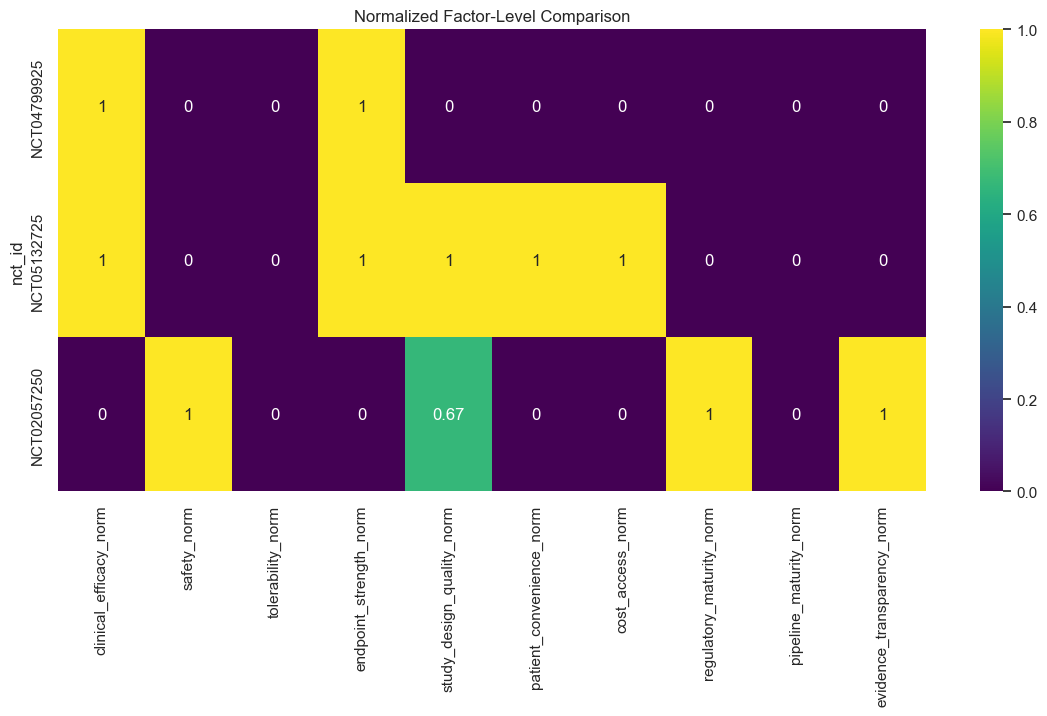

In [21]:
heatmap_cols = [
    'clinical_efficacy_norm',
    'safety_norm',
    'tolerability_norm',
    'endpoint_strength_norm',
    'study_design_quality_norm',
    'patient_convenience_norm',
    'cost_access_norm',
    'regulatory_maturity_norm',
    'pipeline_maturity_norm',
    'evidence_transparency_norm'
]

available_heatmap_cols = [c for c in heatmap_cols if c in scored_df.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(
    scored_df.set_index('nct_id')[available_heatmap_cols],
    annot=True,
    cmap='viridis',
    vmin=0,
    vmax=1
)
plt.title('Normalized Factor-Level Comparison')
plt.show()


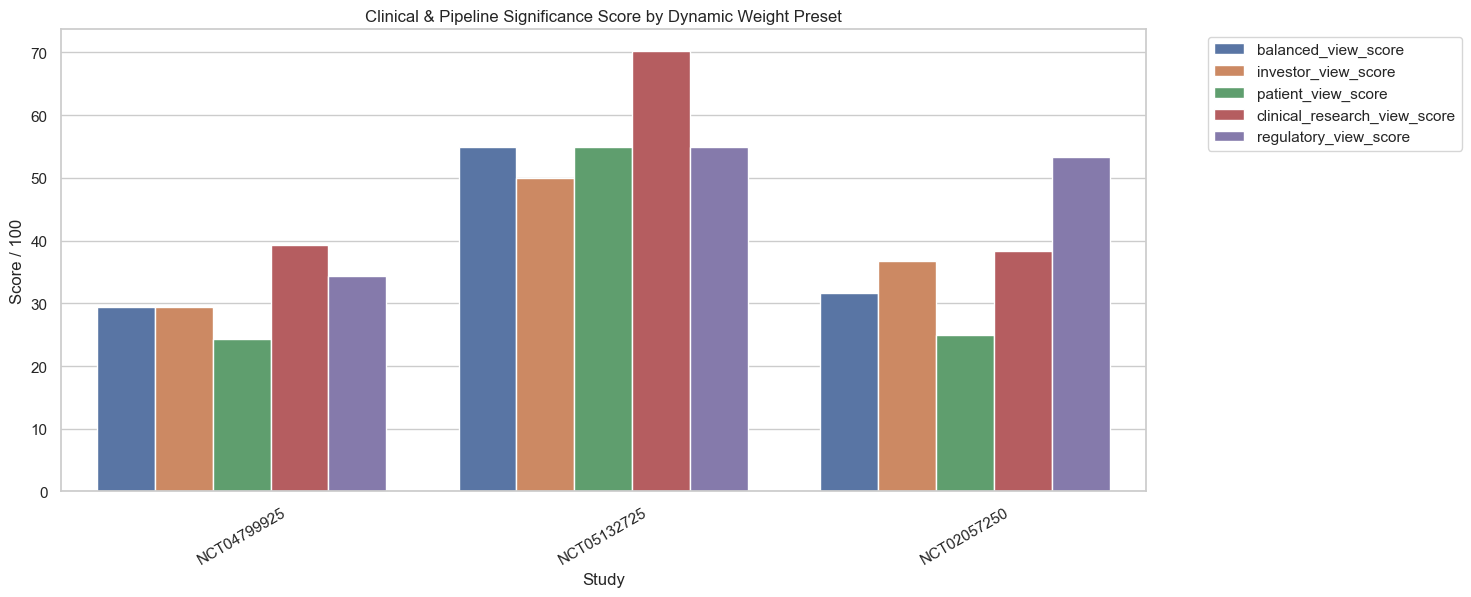

In [22]:
score_cols = [
    'balanced_view_score',
    'investor_view_score',
    'patient_view_score',
    'clinical_research_view_score',
    'regulatory_view_score'
]

plot_df = scored_df[['nct_id'] + score_cols].melt(
    id_vars='nct_id',
    var_name='view',
    value_name='score'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='nct_id', y='score', hue='view')
plt.title('Clinical & Pipeline Significance Score by Dynamic Weight Preset')
plt.ylabel('Score / 100')
plt.xlabel('Study')
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


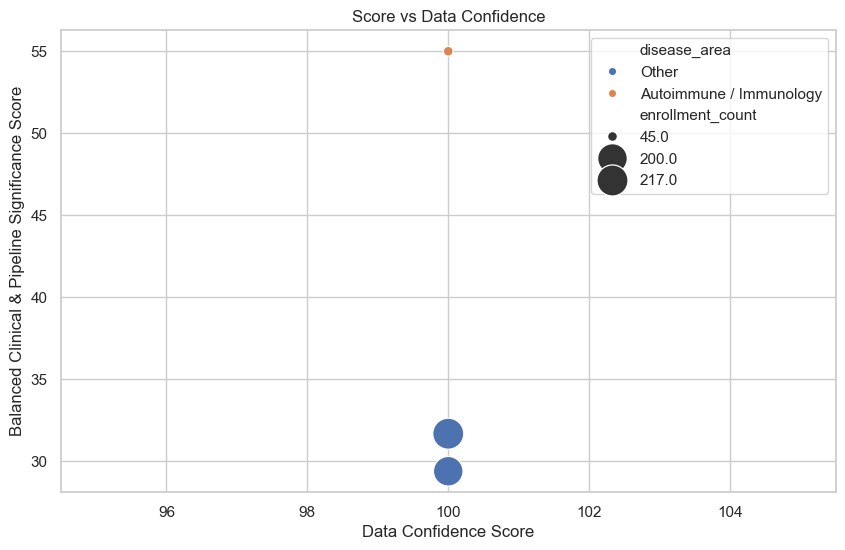

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scored_df,
    x='data_confidence_score',
    y='balanced_view_score',
    hue='disease_area',
    size='enrollment_count',
    sizes=(50, 500)
)
plt.title('Score vs Data Confidence')
plt.xlabel('Data Confidence Score')
plt.ylabel('Balanced Clinical & Pipeline Significance Score')
plt.show()


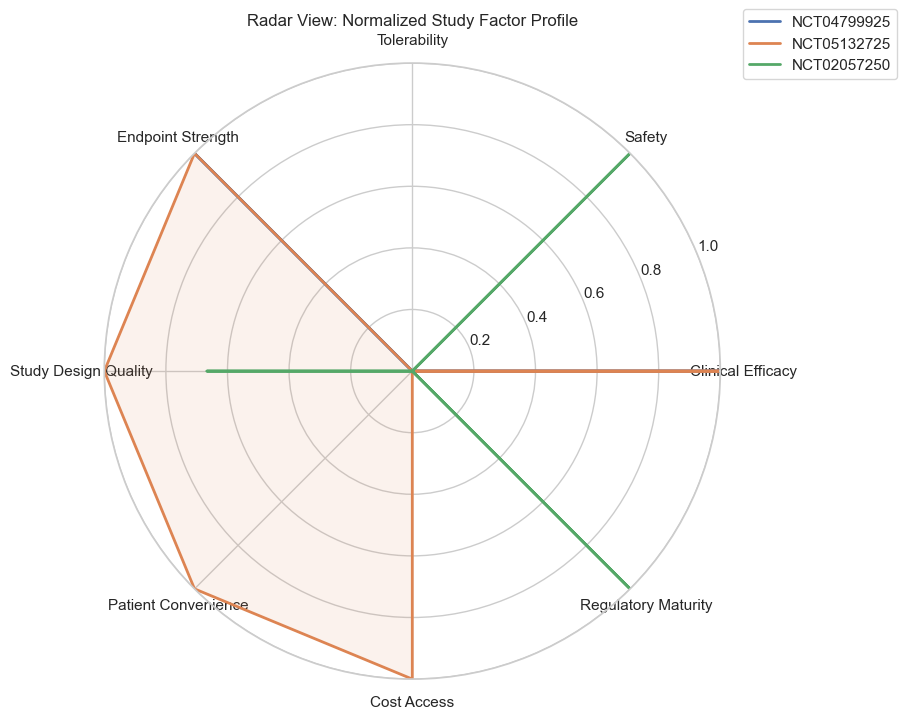

In [24]:
def plot_radar_for_studies(scored_df, nct_ids, factor_cols):
    labels = [c.replace('_norm', '').replace('_', ' ').title() for c in factor_cols]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for nct_id in nct_ids:
        row = scored_df[scored_df['nct_id'] == nct_id]
        if row.empty:
            continue

        values = row[factor_cols].iloc[0].fillna(0).tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=nct_id)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    plt.title('Radar View: Normalized Study Factor Profile')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

radar_cols = available_heatmap_cols[:8]
plot_radar_for_studies(scored_df, scored_df['nct_id'].tolist(), radar_cols)


In [25]:
def generate_strengths_risks(row):
    strengths = []
    risks = []
    missing = []

    if row.get('phase_numeric', 0) >= 3:
        strengths.append('Late-stage clinical development signal')
    elif row.get('phase_numeric', 0) <= 1:
        risks.append('Early-stage evidence only')

    if row.get('enrollment_count', 0) >= 200:
        strengths.append('Moderate-to-large enrollment')
    elif row.get('enrollment_count', 0) < 50:
        risks.append('Small enrollment size')

    if row.get('has_results', 0) == 1:
        strengths.append('Results are available in the source record')
    else:
        missing.append('No posted results found in ClinicalTrials.gov record')

    if row.get('publication_count', 0) > 0:
        strengths.append('Linked publication evidence available')
    else:
        missing.append('No linked publication found')

    if row.get('primary_endpoint_count', 0) > 0:
        strengths.append('Primary endpoint available')
    else:
        risks.append('Primary endpoint not clearly available')

    if row.get('is_randomized', 0) == 1:
        strengths.append('Randomized design signal')
    else:
        risks.append('Randomization not clearly identified')

    if row.get('has_masking', 0) == 1:
        strengths.append('Masking/blinding signal available')
    else:
        risks.append('Masking/blinding not clearly identified')

    if row.get('country_count', 0) > 1:
        strengths.append('Multi-country study signal')
    else:
        risks.append('Limited geographic diversity based on available locations')

    if row.get('is_negative_status', 0) == 1:
        risks.append('Terminated, withdrawn, or suspended status signal')

    return {
        'strengths': strengths,
        'risks': risks,
        'missing_data': missing
    }

flags = scored_df.apply(generate_strengths_risks, axis=1)
scored_df['strengths'] = flags.apply(lambda x: x['strengths'])
scored_df['risks'] = flags.apply(lambda x: x['risks'])
scored_df['missing_data'] = flags.apply(lambda x: x['missing_data'])

display(scored_df[['nct_id', 'strengths', 'risks', 'missing_data']])


,nct_id,strengths,risks,missing_data
0,NCT04799925,"[Moderate-to-large enrollment, Primary endpoint available]","[Early-stage evidence only, Randomization not clearly identified, Masking/blinding not clearly identified, Limited geographic diversity based on available l...","[No posted results found in ClinicalTrials.gov record, No linked publication found]"
1,NCT05132725,"[Primary endpoint available, Randomized design signal, Masking/blinding signal available]","[Early-stage evidence only, Small enrollment size, Limited geographic diversity based on available locations]","[No posted results found in ClinicalTrials.gov record, No linked publication found]"
2,NCT02057250,"[Moderate-to-large enrollment, Results are available in the source record, Primary endpoint available, Randomized design signal, Multi-country study signal]","[Early-stage evidence only, Masking/blinding not clearly identified]",[No linked publication found]


In [26]:
def build_pipeline_summary(df):
    temp = df.copy()

    temp['enrollment'] = pd.to_numeric(temp['enrollment'], errors='coerce')
    temp['phase_numeric'] = temp['phase'].apply(phase_to_numeric)
    temp['status_norm'] = temp['status'].fillna('').str.lower()

    group_cols = ['category', 'sponsor', 'phase', 'status']

    pipeline = temp.groupby(group_cols).agg(
        number_of_studies=('nct_id', 'count'),
        average_enrollment=('enrollment', 'mean'),
        max_enrollment=('enrollment', 'max'),
        average_phase_numeric=('phase_numeric', 'mean'),
    ).reset_index()

    pipeline['completed_flag'] = pipeline['status'].str.lower().str.contains('completed', na=False)
    pipeline['active_flag'] = pipeline['status'].str.lower().str.contains('recruiting|active|not yet', na=False)
    pipeline['negative_status_flag'] = pipeline['status'].str.lower().str.contains('terminated|withdrawn|suspended', na=False)

    return pipeline.sort_values('number_of_studies', ascending=False)

pipeline_summary_df = build_pipeline_summary(df)
display(pipeline_summary_df.head(30))


,category,sponsor,phase,status,number_of_studies,average_enrollment,max_enrollment,average_phase_numeric,completed_flag,active_flag,negative_status_flag
1991,Oncology,National Cancer Institute (NCI),PHASE2,COMPLETED,31,43.516129,101,0.0,True,False,False
632,Autoimmune,Novo Nordisk A/S,PHASE3,COMPLETED,26,916.692308,9341,0.0,True,False,False
629,Autoimmune,Novo Nordisk A/S,PHASE1,COMPLETED,21,64.619048,384,0.0,True,False,False
1986,Oncology,National Cancer Institute (NCI),PHASE1,COMPLETED,20,32.750000,58,0.0,True,False,False
1858,Oncology,M.D. Anderson Cancer Center,PHASE2,COMPLETED,16,63.062500,197,0.0,True,False,False
263,Autoimmune,Eli Lilly and Company,PHASE3,COMPLETED,14,1131.714286,9901,0.0,True,False,False
1852,Oncology,M.D. Anderson Cancer Center,PHASE1,COMPLETED,12,25.416667,63,0.0,True,False,False
1677,Oncology,Hoffmann-La Roche,PHASE3,COMPLETED,11,782.272727,2185,0.0,True,False,False
92,Autoimmune,AstraZeneca,PHASE3,COMPLETED,9,2335.444444,17190,0.0,True,False,False
758,Autoimmune,Sanofi,PHASE4,COMPLETED,9,1064.888889,7376,0.0,True,False,False


/var/folders/6c/_s9vdlvj0z3dmgnwfhss_9lm0000gq/T/ipykernel_56218/4119430006.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='phase', y='enrollment', ax=axes[2,0], palette='coolwarm')


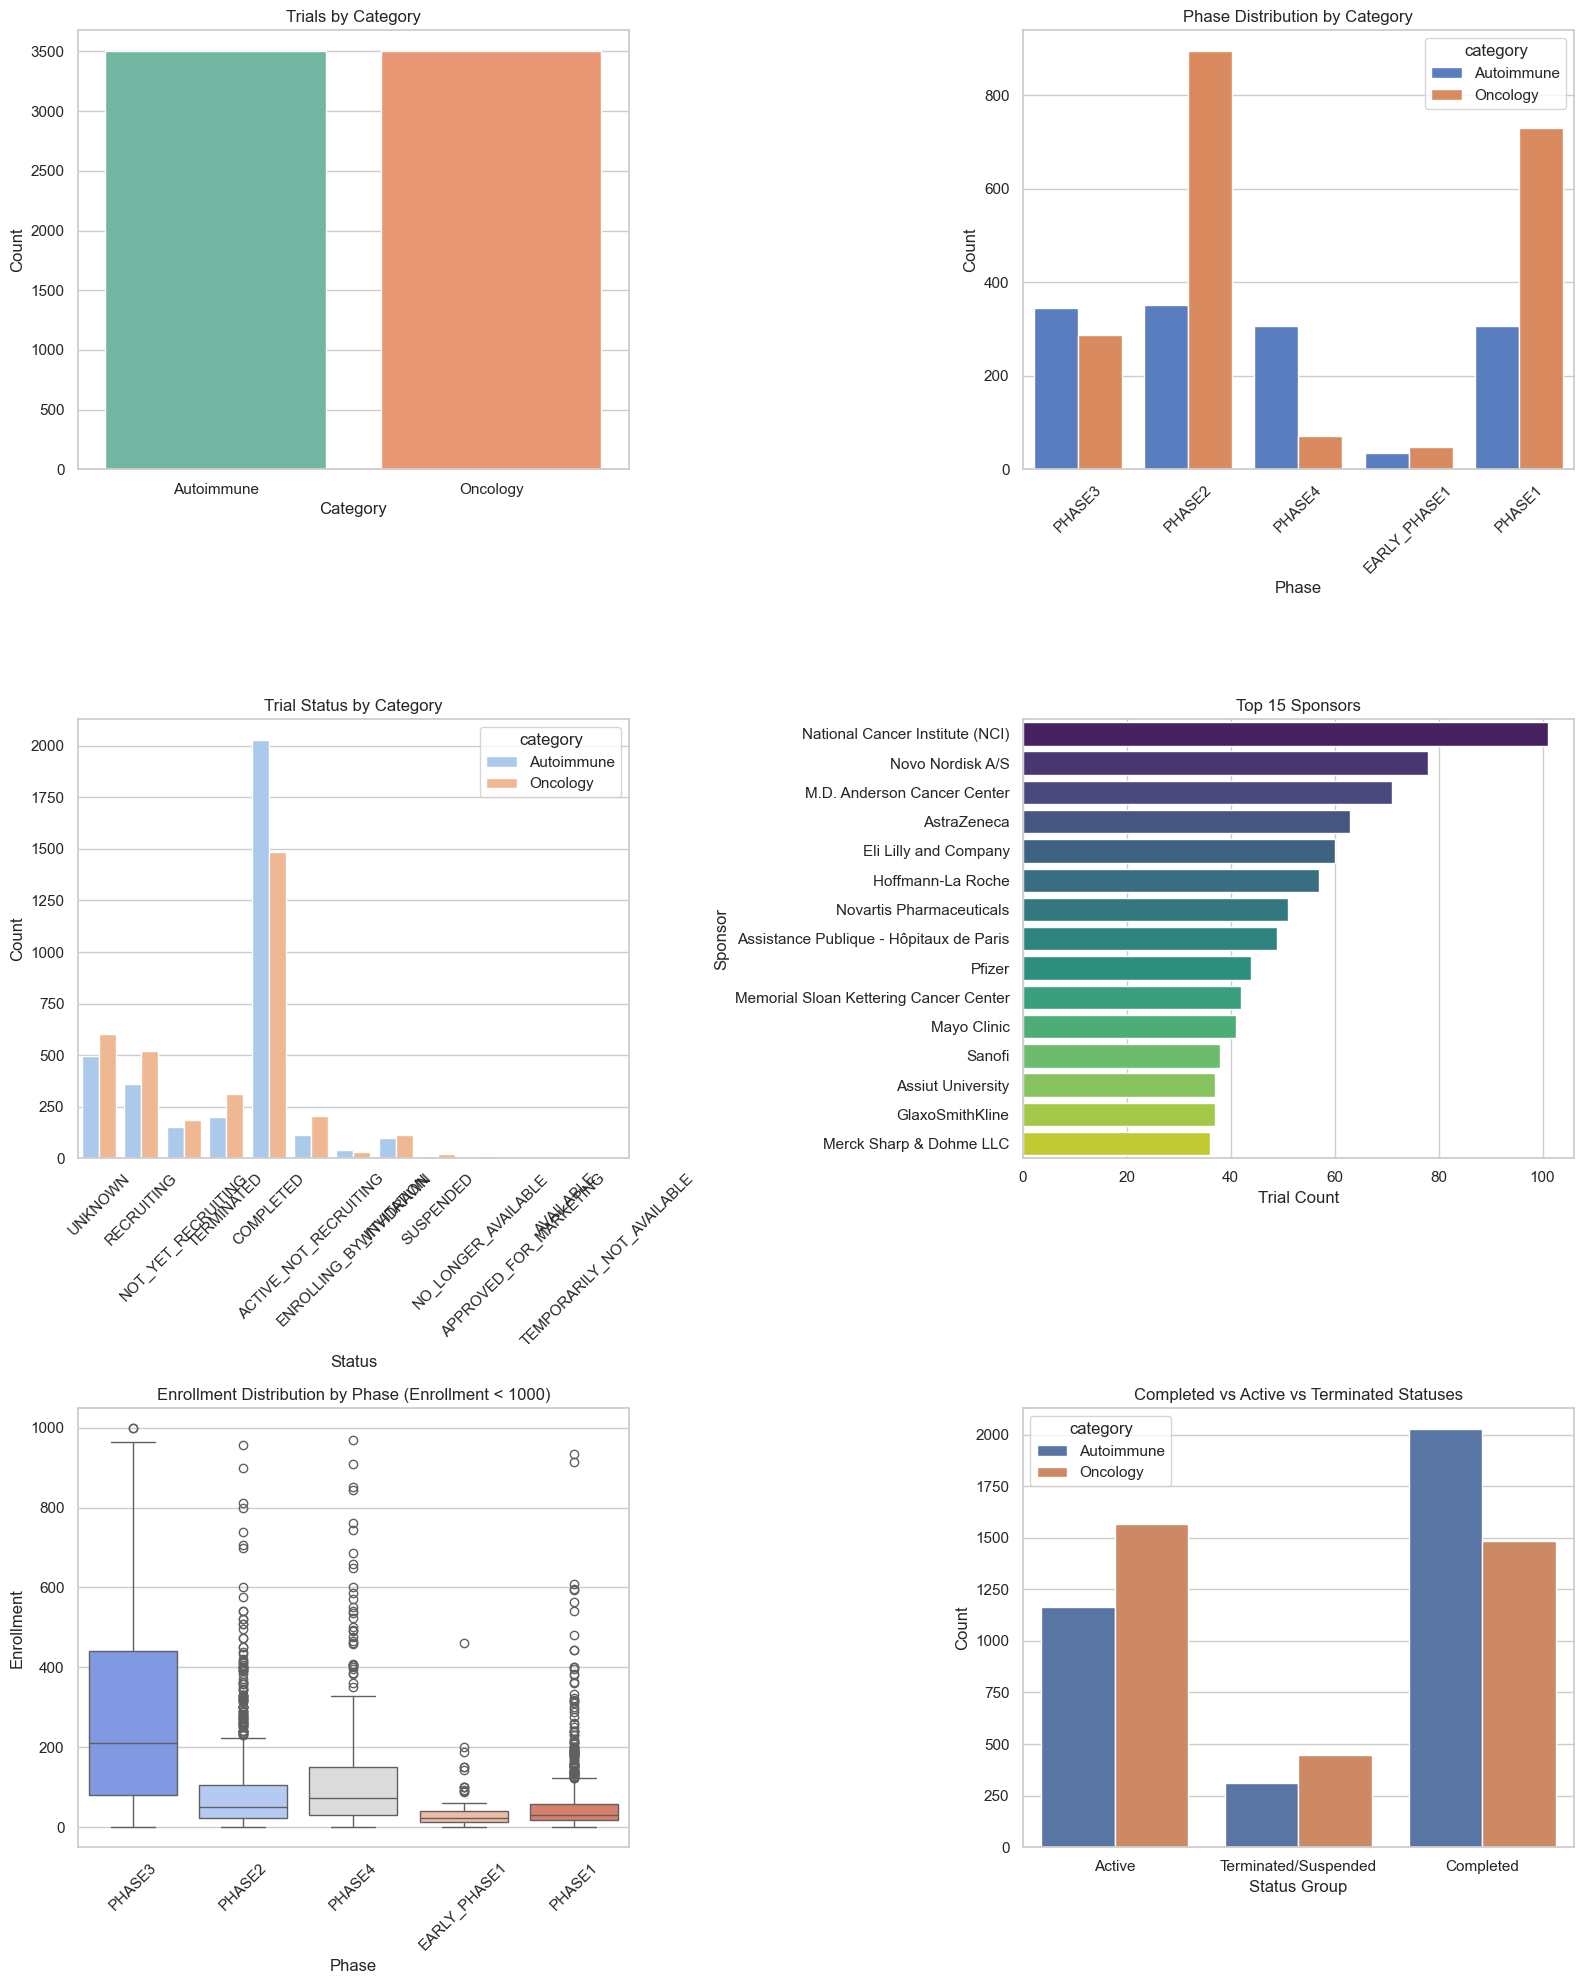

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. Trials by category
sns.countplot(data=df, x='category', ax=axes[0,0], hue='category', legend=False, palette='Set2')
axes[0,0].set_title('Trials by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Count')

# 2. Phase by category
sns.countplot(data=df, x='phase', hue='category', ax=axes[0,1], palette='muted')
axes[0,1].set_title('Phase Distribution by Category')
axes[0,1].set_xlabel('Phase')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Status by category
sns.countplot(data=df, x='status', hue='category', ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Trial Status by Category')
axes[1,0].set_xlabel('Status')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Top 15 sponsors
top_sponsors = df['sponsor'].value_counts().head(15).reset_index()
sns.barplot(data=top_sponsors, y='sponsor', x='count', ax=axes[1,1], hue='sponsor', legend=False, palette='viridis')
axes[1,1].set_title('Top 15 Sponsors')
axes[1,1].set_xlabel('Trial Count')
axes[1,1].set_ylabel('Sponsor')

# 5. Enrollment by phase
df_temp = df.copy()
df_temp['enrollment'] = pd.to_numeric(df_temp['enrollment'], errors='coerce')
df_temp = df_temp[df_temp['enrollment'] < 1000]  # Filter extreme outliers for plotting
sns.boxplot(data=df_temp, x='phase', y='enrollment', ax=axes[2,0], palette='coolwarm')
axes[2,0].set_title('Enrollment Distribution by Phase (Enrollment < 1000)')
axes[2,0].set_xlabel('Phase')
axes[2,0].set_ylabel('Enrollment')
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Completed vs active vs terminated
df_status = df.copy()
df_status['status_class'] = 'Active'
df_status.loc[df_status['status'].fillna('').str.lower().str.contains('completed'), 'status_class'] = 'Completed'
df_status.loc[df_status['status'].fillna('').str.lower().str.contains('terminated|withdrawn|suspended'), 'status_class'] = 'Terminated/Suspended'
sns.countplot(data=df_status, x='status_class', hue='category', ax=axes[2,1], palette='deep')
axes[2,1].set_title('Completed vs Active vs Terminated Statuses')
axes[2,1].set_xlabel('Status Group')
axes[2,1].set_ylabel('Count')

plt.tight_layout()
plt.show()


## Competitive Benchmark: Why This Matters

Large clinical intelligence platforms focus on trial design, enrollment timelines, patient populations, endpoints, outcomes, geography, sites, investigators, and drug development pipelines.

MindReader’s opportunity is to create a more explainable decision layer:
- Start from public clinical trial data
- Extract comparable structured factors
- Normalize factors into a common scale
- Apply dynamic weights depending on user view
- Produce a transparent Clinical & Pipeline Significance Score
- Explain why a study or pipeline looks strong, weak, risky, or incomplete

This does not replace enterprise clinical databases. It demonstrates an approval-ready method for turning complex trial data into understandable biotech intelligence.

### Industry Context:
- **Reference platform**: Citeline
- **Reference website**: [Citeline](https://www.citeline.com/en/)
- **MindReader site**: [MindReader Biotech](https://www.mindreaderbio.tech/)

Do not copy Citeline’s product. Use it only as market context.


In [28]:
def generate_plain_english_interpretation(scored_df, selected_score_col='balanced_view_score'):
    if scored_df.empty:
        return 'No studies available for interpretation.'

    best = scored_df.sort_values(selected_score_col, ascending=False).iloc[0]
    weakest = scored_df.sort_values(selected_score_col, ascending=True).iloc[0]
    lowest_conf = scored_df.sort_values('data_confidence_score', ascending=True).iloc[0]

    lines = []

    lines.append('## So What It Means')
    lines.append('')
    lines.append(
        f"Based on the selected scoring view, **{best['nct_id']}** has the strongest Clinical & Pipeline Significance Score "
        f"({best[selected_score_col]}/100). This appears to be driven by factors such as endpoint strength, study maturity, design quality, "
        f"results/publication transparency, patient convenience, and pipeline context where available."
    )
    lines.append('')
    lines.append(
        f"**{weakest['nct_id']}** has the lowest score in this selected comparison ({weakest[selected_score_col]}/100). "
        f"This does not mean the therapy failed. It means the available structured data gives weaker evidence or more missing/risk signals under the current weighting method."
    )
    lines.append('')
    lines.append(
        f"The study with the lowest data confidence is **{lowest_conf['nct_id']}** ({lowest_conf['data_confidence_score']}/100). "
        f"This means its score should be interpreted carefully because some source fields are missing or incomplete."
    )
    lines.append('')
    lines.append('### Key Reminder')
    lines.append('')
    lines.append(
        'A low score in the comparison does not represent a lack of therapeutic potential or clinical failure. '
        'It indicates that under the active weighting preset (e.g., balanced, patient, or investor view), the study '
        'has fewer of the positive structural indicators (such as late-stage phase, high enrollment, posted results, or '
        'highly convenient modality like oral administration) or carries specific penalties (like negative overall status or missing endpoints).'
    )
    lines.append('')
    lines.append('### Transparent Score Breakdown')
    for idx, row in scored_df.iterrows():
        lines.append(f"- **{row['nct_id']} ({row['sponsor']})**:")
        lines.append(f"  - Clinical & Pipeline Significance Score ({selected_score_col}): **{row[selected_score_col]}/100**")
        lines.append(f"  - Data Confidence Score: **{row['data_confidence_score']}/100**")
        
        # Breakdown of contributing factors
        breakdown = row.get(f"{selected_score_col.replace('_score', '')}_breakdown", {})
        lines.append('  - Major Contributing Dimension Contributions:')
        for dim, details in breakdown.items():
            if details.get('weighted_contribution', 0) > 0.01:
                lines.append(f"    - {dim.replace('_', ' ').title()}: {round(details['weighted_contribution'] * 100, 1)} points (Normalized Value: {details['normalized_value']}, Weight: {details['weight']})")
        
        penalties = row.get(f"{selected_score_col.replace('_score', '')}_penalty", 0)
        reasons = row.get(f"{selected_score_col.replace('_score', '')}_penalty_reasons", [])
        if penalties > 0:
            lines.append(f"  - Applied Penalties: -{round(penalties, 1)} points due to: {', '.join(reasons)}")
            
    return '\n'.join(lines)

interpretation_md = generate_plain_english_interpretation(scored_df, 'balanced_view_score')
from IPython.display import Markdown
display(Markdown(interpretation_md))


## So What It Means

Based on the selected scoring view, **NCT05132725** has the strongest Clinical & Pipeline Significance Score (55.0/100). This appears to be driven by factors such as endpoint strength, study maturity, design quality, results/publication transparency, patient convenience, and pipeline context where available.

**NCT04799925** has the lowest score in this selected comparison (29.38/100). This does not mean the therapy failed. It means the available structured data gives weaker evidence or more missing/risk signals under the current weighting method.

The study with the lowest data confidence is **NCT04799925** (100.0/100). This means its score should be interpreted carefully because some source fields are missing or incomplete.

### Key Reminder

A low score in the comparison does not represent a lack of therapeutic potential or clinical failure. It indicates that under the active weighting preset (e.g., balanced, patient, or investor view), the study has fewer of the positive structural indicators (such as late-stage phase, high enrollment, posted results, or highly convenient modality like oral administration) or carries specific penalties (like negative overall status or missing endpoints).

### Transparent Score Breakdown
- **NCT04799925 (Assiut University)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **29.38/100**
  - Data Confidence Score: **100.0/100**
  - Major Contributing Dimension Contributions:
    - Clinical Efficacy: 20.0 points (Normalized Value: 1.0, Weight: 0.2)
    - Endpoint Strength: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
  - Applied Penalties: -0.6 points due to: Pipeline termination-risk penalty
- **NCT05132725 (University of Jordan)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **55.0/100**
  - Data Confidence Score: **100.0/100**
  - Major Contributing Dimension Contributions:
    - Clinical Efficacy: 20.0 points (Normalized Value: 1.0, Weight: 0.2)
    - Endpoint Strength: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Study Design Quality: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Patient Convenience: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Cost Access: 5.0 points (Normalized Value: 1.0, Weight: 0.05)
- **NCT02057250 (Sanofi)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **31.67/100**
  - Data Confidence Score: **100.0/100**
  - Major Contributing Dimension Contributions:
    - Safety: 15.0 points (Normalized Value: 1.0, Weight: 0.15)
    - Study Design Quality: 6.7 points (Normalized Value: 0.6667, Weight: 0.1)
    - Regulatory Maturity: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Evidence Transparency: 5.0 points (Normalized Value: 1.0, Weight: 0.05)
  - Applied Penalties: -5.0 points due to: Pipeline termination-risk penalty